# Case no. 1 - air line blockage
Out of six options, we choose the first fault case. 

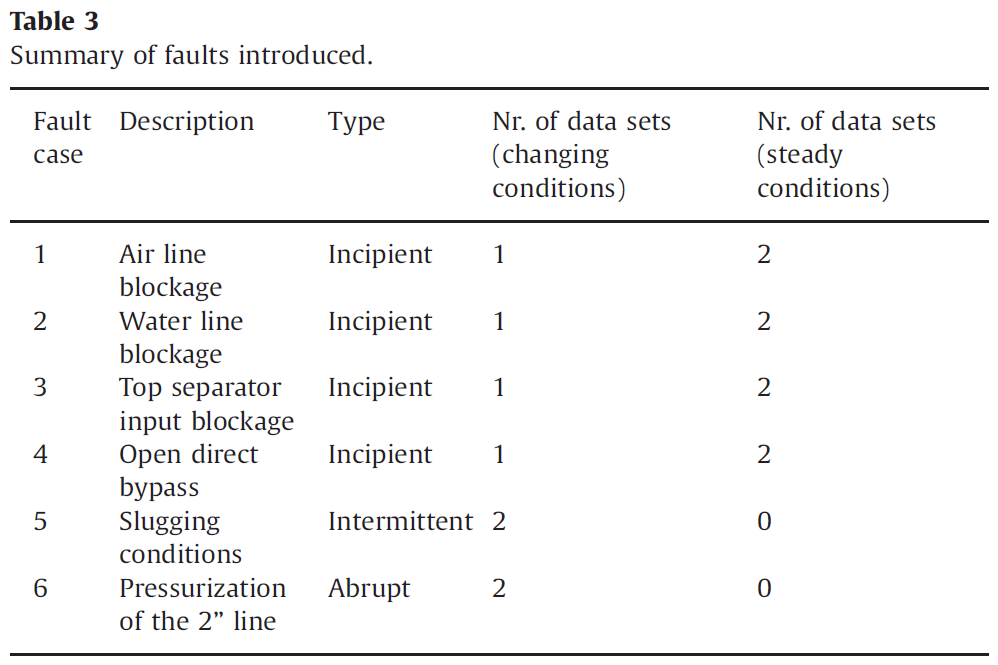

After the fault was introduced to the system, the operation ran with three different configurations. This provides the three data sets called Set1_1, Set1_2 and Set1_3. 

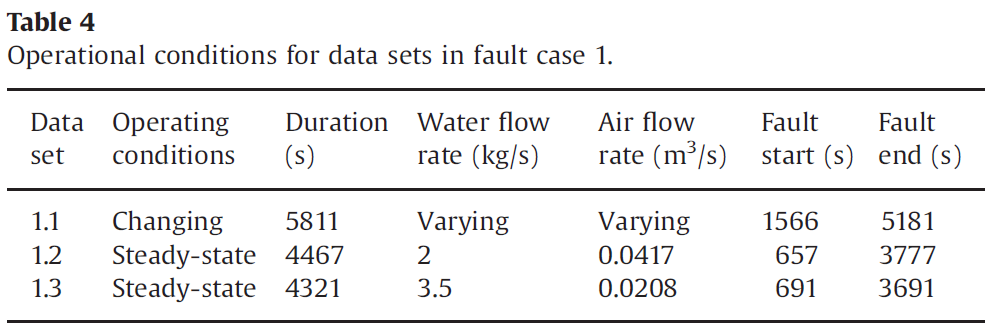

The fault that got introduced to the system is related to the valve position, which can be observed by the three fault data sets. This variable is not available in the training data. 

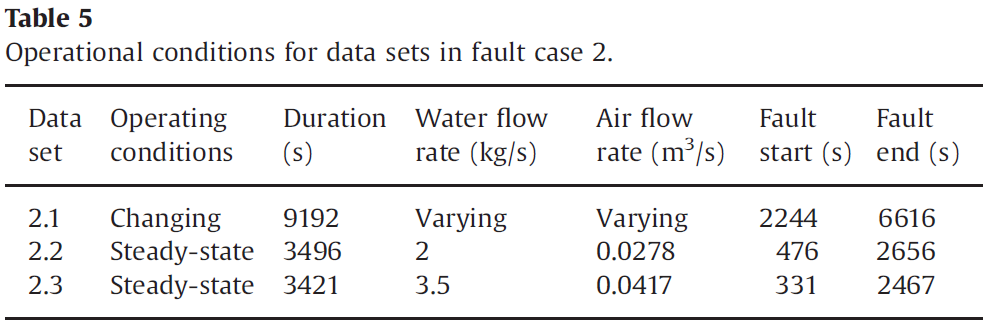

# Loading the data
Operational data - Loaded seperatly and pooled together for a more robust training. 

In [1]:
import scipy.io
import pandas as pd

# 1. Indlæs filen
mat_data = scipy.io.loadmat('CVACaseStudy/FaultyCase1.mat')

# 2. Definer kolonnenavne (v1-v23 jf. Table 1 i artiklen)
# Vi udelader v24 (P_Mixture_2in), da den kun er til Case 6 [cite: 251]
column_names = [
    "Air_Delivery_P", "P_Bottom_Riser", "P_Top_Riser", "P_Top_Separator", 
    "P_3Phase_Separator", "Diff_P_Riser", "Diff_P_VC404", "Air_In_Flow", 
    "Water_In_Flow", "Flow_Top_Riser", "Level_Top_Sep", "Flow_Top_Sep_Out", 
    "Density_Top_Riser", "Density_Top_Sep_Out", "Density_Water_In", 
    "Temp_Top_Riser", "Temp_Top_Sep_Out", "Temp_Water_In", "Level_3Phase_Sep", 
    "Pos_VC501", "Pos_VC302", "Pos_VC101", "Pump_Current_PO1"
]

# 3. Indlæs de tre sæt separat (kun de første 23 kolonner)
# Sæt 1.1: Varying conditions (5811 samples) 
df1_1 = pd.DataFrame(mat_data['Set1_1'][:, :23], columns=column_names)
df1_1['Source'] = 'Set1_1'

# Sæt 1.2: Steady-state (4467 samples) 
df1_2 = pd.DataFrame(mat_data['Set1_2'][:, :23], columns=column_names)
df1_2['Source'] = 'Set1_2'

# Sæt 1.3: Steady-state (4321 samples) 
df1_3 = pd.DataFrame(mat_data['Set1_3'][:, :23], columns=column_names)
df1_3['Source'] = 'Set1_3'

# 4. Lav den kombinerede tabel (Concat)
# Dette svarer til artiklens metode med at kombinere træningssæt [cite: 428]
# df_combined = pd.concat([df1_1, df1_2, df1_3], ignore_index=True)

# 5. Status print
print(f"Set 1.1 klar: {df1_1.shape}")
print(f"Set 1.2 klar: {df1_2.shape}")
print(f"Set 1.3 klar: {df1_3.shape}")
#print(f"---")
#print(f"Kombineret tabel klar: {df_combined.shape}") # Bør give (14600, 24 inkl. Source)

Set 1.1 klar: (5811, 24)
Set 1.2 klar: (4467, 24)
Set 1.3 klar: (4321, 24)


Fault data for ground truthing - This is not pooled together because we want to test each scenario seperatly to see what faults the final model will be able to detect.

In [2]:
import pandas as pd

# Vi bruger v1-v23 som defineret i artiklens Table 1
column_names_sensors = column_names[:23] 

# --- DATASET 1.1 (Changing Conditions) ---
# Sensordata (Test data)
df1_1_sensors = pd.DataFrame(mat_data['Set1_1'][:, :23], columns=column_names_sensors)
# Ground Truth (Valve position / Fault evolution)
df1_1_gt = pd.DataFrame(mat_data['EvoFault1_1'], columns=["Valve_Opening_Percent"])

# --- DATASET 1.2 (Steady-state 1) ---
df1_2_sensors = pd.DataFrame(mat_data['Set1_2'][:, :23], columns=column_names_sensors)
df1_2_gt = pd.DataFrame(mat_data['EvoFault1_2'], columns=["Valve_Opening_Percent"])

# --- DATASET 1.3 (Steady-state 2) ---
df1_3_sensors = pd.DataFrame(mat_data['Set1_3'][:, :23], columns=column_names_sensors)
df1_3_gt = pd.DataFrame(mat_data['EvoFault1_3'], columns=["Valve_Opening_Percent"])

# Status check
print(f"Set 1.1: Sensors {df1_1_sensors.shape}, Ground Truth {df1_1_gt.shape}")
print(f"Set 1.2: Sensors {df1_2_sensors.shape}, Ground Truth {df1_2_gt.shape}")
print(f"Set 1.3: Sensors {df1_3_sensors.shape}, Ground Truth {df1_3_gt.shape}")

Set 1.1: Sensors (5811, 23), Ground Truth (5811, 1)
Set 1.2: Sensors (4467, 23), Ground Truth (4467, 1)
Set 1.3: Sensors (4321, 23), Ground Truth (4321, 1)


## Visulization of faults
It looks like three different faults, although they are only marginally different.

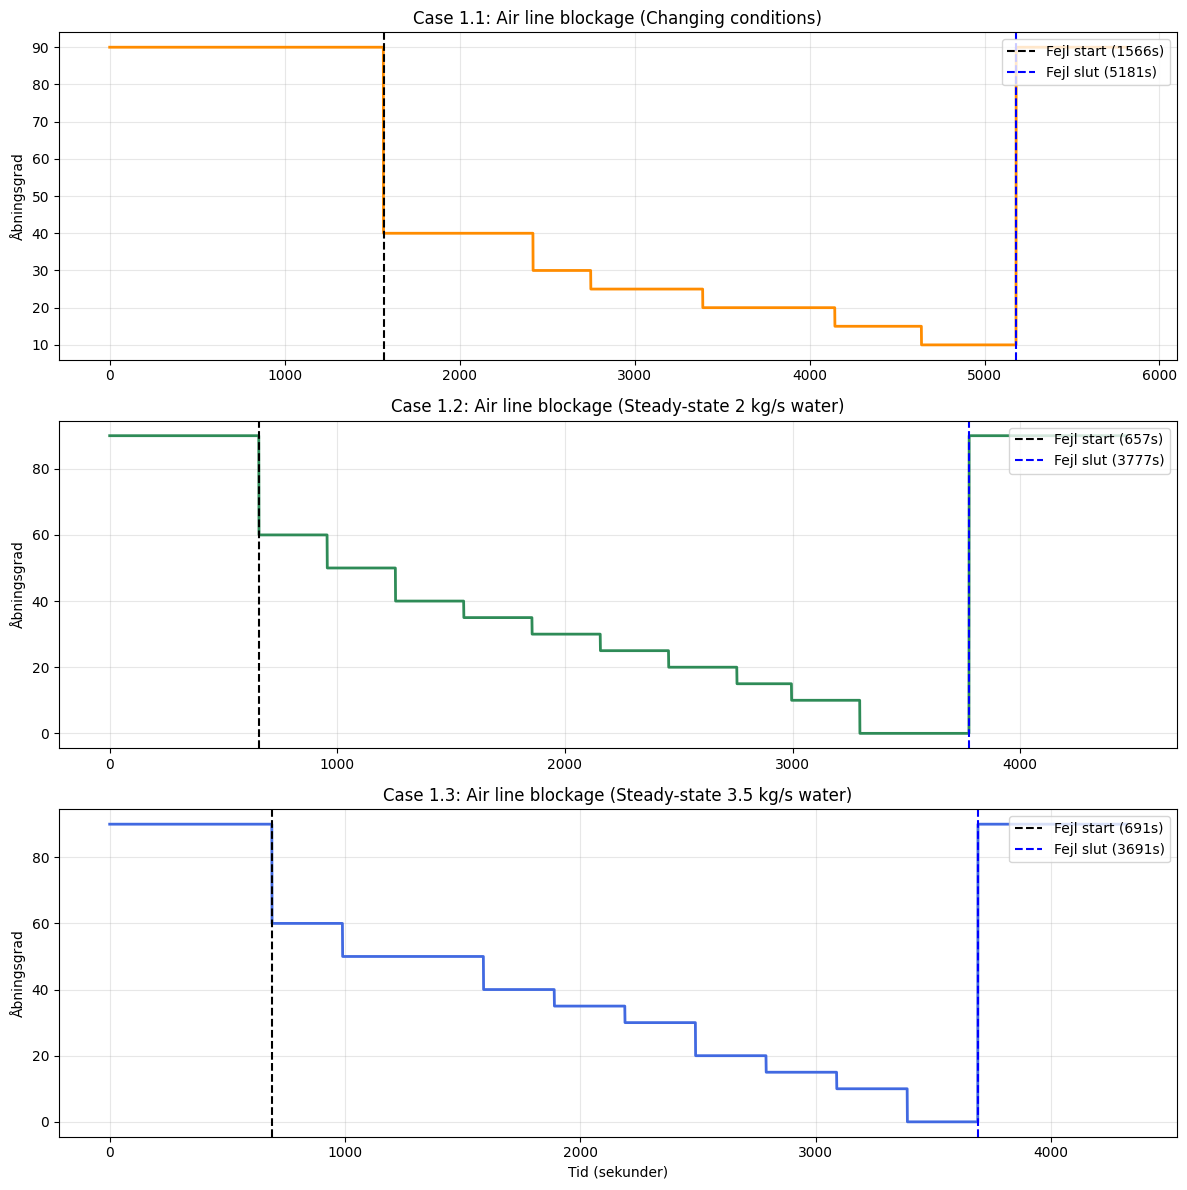

In [3]:
import matplotlib.pyplot as plt

# Vi opretter en figur med 3 subplots under hinanden
fig, axes = plt.subplots(3, 1, figsize=(12, 12), sharex=False)

# --- Plot for Sæt 1.1 (Changing conditions) ---
axes[0].plot(df1_1_gt["Valve_Opening_Percent"], color='darkorange', linewidth=2)
axes[0].axvline(x=1566, color='black', linestyle='--', label='Fejl start (1566s)') 
axes[0].axvline(x=5181, color='blue', linestyle='--', label='Fejl slut (5181s)') 
axes[0].set_title("Case 1.1: Air line blockage (Changing conditions)")
axes[0].set_ylabel("Åbningsgrad")
axes[0].legend(loc='upper right')
axes[0].grid(True, alpha=0.3)

# --- Plot for Sæt 1.2 (Steady-state 1) ---
axes[1].plot(df1_2_gt["Valve_Opening_Percent"], color='seagreen', linewidth=2)
axes[1].axvline(x=657, color='black', linestyle='--', label='Fejl start (657s)') 
axes[1].axvline(x=3777, color='blue', linestyle='--', label='Fejl slut (3777s)') 
axes[1].set_title("Case 1.2: Air line blockage (Steady-state 2 kg/s water)")
axes[1].set_ylabel("Åbningsgrad")
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.3)

# --- Plot for Sæt 1.3 (Steady-state 2) ---
axes[2].plot(df1_3_gt["Valve_Opening_Percent"], color='royalblue', linewidth=2)
axes[2].axvline(x=691, color='black', linestyle='--', label='Fejl start (691s)') 
axes[2].axvline(x=3691, color='blue', linestyle='--', label='Fejl slut (3691s)') 
axes[2].set_title("Case 1.3: Air line blockage (Steady-state 3.5 kg/s water)")
axes[2].set_xlabel("Tid (sekunder)")
axes[2].set_ylabel("Åbningsgrad")
axes[2].legend(loc='upper right')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Visualization of operational data
This is only done for data set 1.1 to save room. The fault period is marked on the graphs, but of course this is not available information for the model.

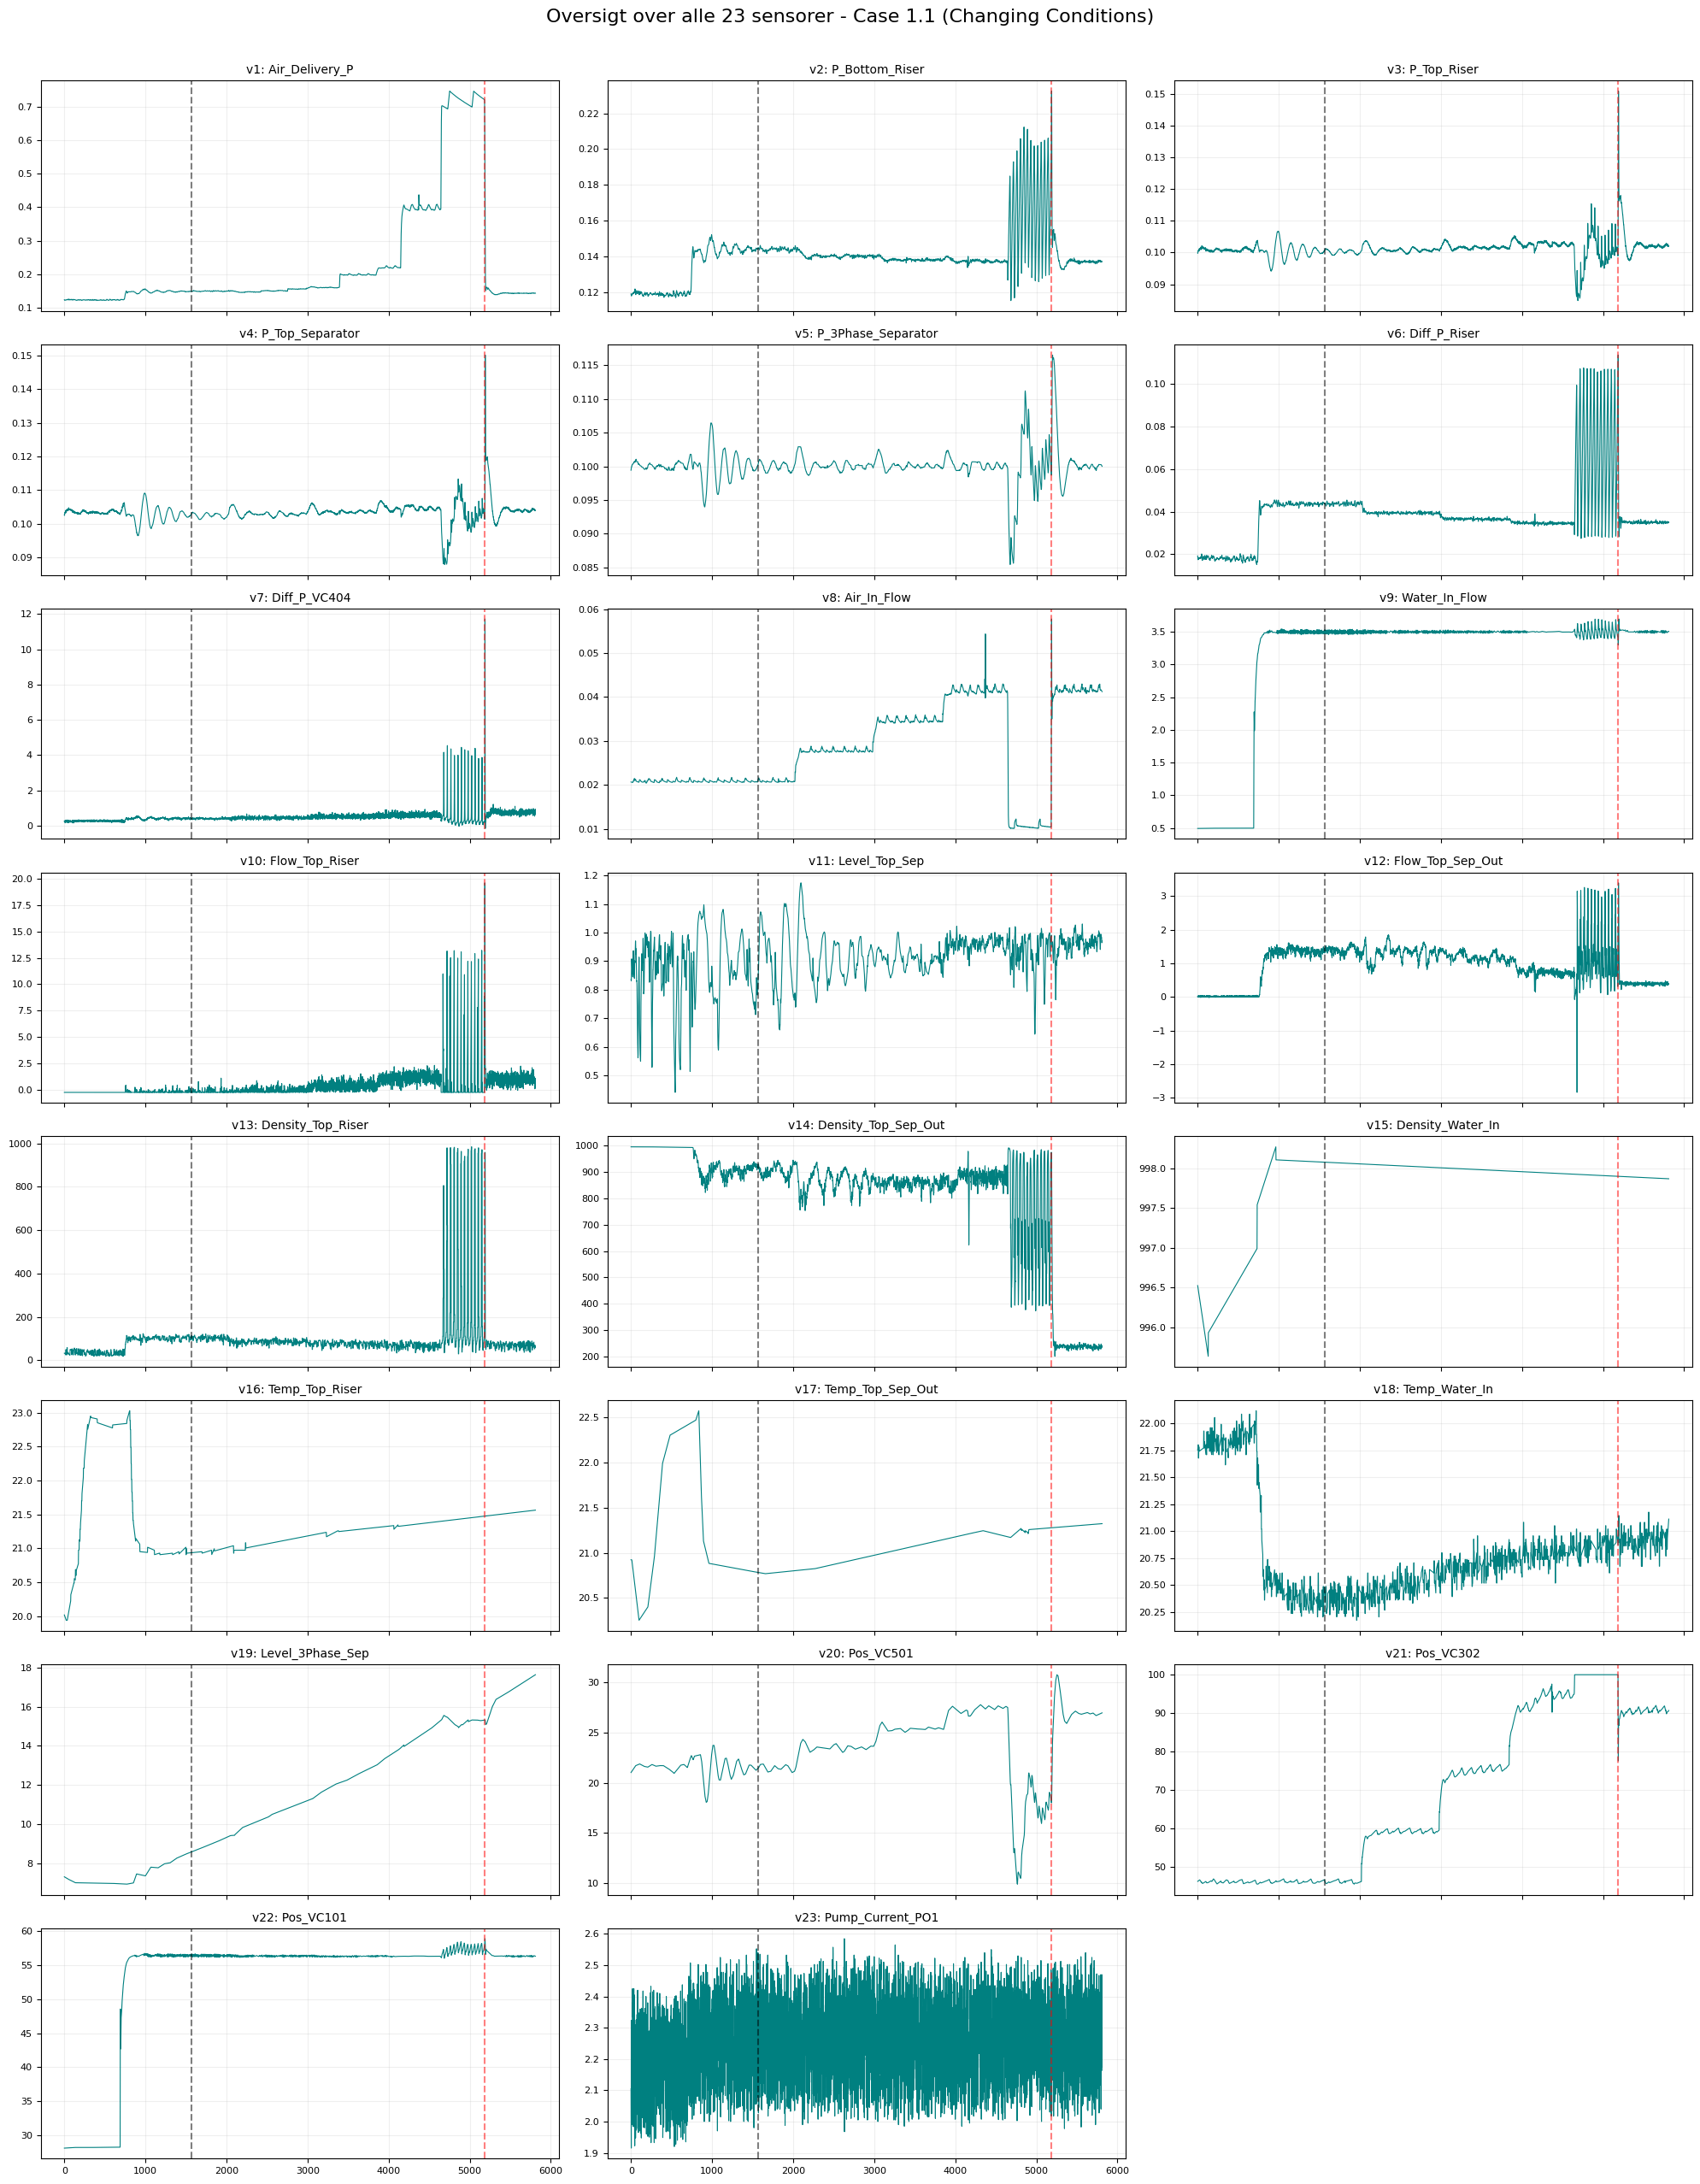

In [4]:
import matplotlib.pyplot as plt

# Vi henter de 23 kolonnenavne vi definerede tidligere
sensors_to_plot = column_names[:23]

# Vi opretter et grid (f.eks. 8 rækker og 3 kolonner for at få plads til alle 23)
fig, axes = plt.subplots(nrows=8, ncols=3, figsize=(20, 25), sharex=True)
axes = axes.flatten() # Gør grid'et fladt så vi kan køre en simpel løkke

for i, sensor in enumerate(sensors_to_plot):
    axes[i].plot(df1_1_sensors[sensor], color='teal', linewidth=0.8)
    
    # Markér fejlens start og slut (Case 1.1: 1566s til 5181s) [cite: 340]
    axes[i].axvline(x=1566, color='black', linestyle='--', alpha=0.5)
    axes[i].axvline(x=5181, color='red', linestyle='--', alpha=0.5)
    
    axes[i].set_title(f"v{i+1}: {sensor}", fontsize=10)
    axes[i].grid(True, alpha=0.2)
    axes[i].tick_params(labelsize=8)

# Skjul de overskydende subplots (da 8x3 = 24, men vi kun har 23 sensorer)
if len(sensors_to_plot) < len(axes):
    for j in range(len(sensors_to_plot), len(axes)):
        fig.delaxes(axes[j])

plt.tight_layout()
plt.suptitle("Oversigt over alle 23 sensorer - Case 1.1 (Changing Conditions)", y=1.02, fontsize=16)
plt.show()

# PCA model 
Generalized with data from all three system configurations, but only the data from before the faults occured. 

This includes removal of outliers and scaling.

In [5]:
import numpy as np
import pandas as pd
from scipy import stats
from scipy.stats import f
import matplotlib.pyplot as plt

# Tidsstempler for fejl-start jf. artiklen (Tabel 4)
# Set 1.1: 1566s | Set 1.2: 657s | Set 1.3: 691s

# Vi udtrækker de normale rækker (før fejlen starter)
train_1_1 = df1_1_sensors.iloc[:1566]
train_1_2 = df1_2_sensors.iloc[:657]
train_1_3 = df1_3_sensors.iloc[:691]

# Vi samler dem til én robust trænings-matrix
X_train_raw = pd.concat([train_1_1, train_1_2, train_1_3], ignore_index=True)

print(f"Antal normale rækker i puljen: {X_train_raw.shape[0]}")
# Bør give ca. 2914 rækker (1566 + 657 + 691)

# Rensning (Interpolation og outliers)
X_train_clean = X_train_raw.interpolate().ffill().bfill()
z = np.abs(stats.zscore(X_train_clean))
X_train_clean = X_train_clean[(z < 3).all(axis=1)]

# GEM DISSE: De er fundamentet for hele jeres detektionsmodel
train_mu = X_train_clean.mean()
train_sigma = X_train_clean.std()

# Normaliser træningsdata (Z-score)
X_train_scaled = (X_train_clean - train_mu) / train_sigma

Antal normale rækker i puljen: 2914


In [6]:
import numpy as np

# Vi bruger den rensede og skalerede pulje fra før
X = X_train_scaled.values 
n = X.shape[0]  # Antal rækker (ca. 2900)
m = X.shape[1]  # Antal sensorer (23)

# 1. Beregn Kovariansmatrix
# np.cov forventer at variabler er i rækkerne, så vi transponerer med .T
R = np.cov(X.T)

# 2. Find egenværdier og egenvektorer (Svarer til SVD i din MATLAB)
eigenvalues, eigenvectors = np.linalg.eig(R)

# 3. Sortér dem (størst først), da de ikke altid kommer i rækkefølge
idx = eigenvalues.argsort()[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

print("De første 10 egenværdier:")
for i, val in enumerate(eigenvalues[:10]):
    print(f"PC{i+1}: {val:.4f}")


De første 10 egenværdier:
PC1: 8.9282
PC2: 6.1881
PC3: 2.3050
PC4: 1.8312
PC5: 1.0948
PC6: 0.9663
PC7: 0.9169
PC8: 0.1984
PC9: 0.1441
PC10: 0.1065


In [7]:
# 4. Vælg antal hovedkomponenter (a)
a = 7 
P = eigenvectors[:, :a] # Dette er din Loading Matrix (V1 i MATLAB)

# 5. Forbered beregning af T2 (Lambda matrix)
# Vi skal bruge den inverse diagonalmatrix af egenværdierne for de valgte komponenter
Sigma_a_inv = np.diag(1.0 / eigenvalues[:a])

print(f"Model trænet på {n} normale samples med {a} komponenter.")

Model trænet på 2747 normale samples med 7 komponenter.


Statistical Threshold

In [8]:
alpha = 0.05
# F-distributionens kritiske værdi: finv(1-alpha, a, n-a)
f_crit = f.ppf(1 - alpha, a, n - a)

# Beregn T2 tærskel (T2_alpha)
T2_threshold = (a * (n - 1) * (n + 1)) / (n * (n - a)) * f_crit

print(f"Antal komponenter (a): {a}")
print(f"T2 Kontrolgrænse (UCL): {T2_threshold:.4f}")

Antal komponenter (a): 7
T2 Kontrolgrænse (UCL): 14.1264


# Testing the model on test1_1


In [ ]:
# Vi tager sensordata fra det fejlbehæftede sæt
X_test_raw = df1_1_sensors.copy() 

# VIGTIGT: Skaler TEST data med TRÆNINGS parametre (mu og sigma)
X_test = (X_test_raw - train_mu) / train_sigma

# Projektion til de valgte komponenter (Scores)
T_test = X_test @ P

# Beregn T2-værdi for hver tidsenhed i test-sættet
# T2 = t * inv(Sigma) * t'
T2_values = np.zeros(len(T_test))
for i in range(len(T_test)):
    score = T_test.iloc[i, :].values
    T2_values[i] = score @ Sigma_a_inv @ score.T

NameError: name 'mu' is not defined

# Results
I jeres projekt fungerer T^2 som et samlet alarmsignal. I stedet for at du skal sidde og holde øje med 23 forskellige grafer for tryk, temperatur og flow, kigger du kun på T^2-grafen.

- Hvis T^2 er lav (under tærsklen), opfører alle 23 sensorer sig præcis, som de gjorde under den normale træningsperiode.

- Hvis T^2 er høj (over tærsklen), er der sket en ændring i systemet, som PCA-modellen ikke genkender som "normal".

Grafen kan laves med en logoritmisk y-akse.

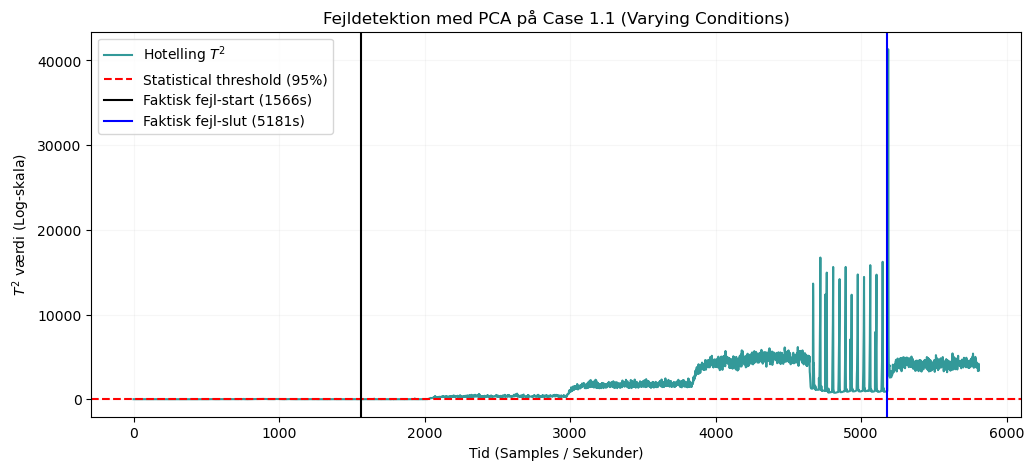

In [ ]:
plt.figure(figsize=(12, 5))
plt.plot(T2_values, label='Hotelling $T^2$', color='teal', alpha=0.8)

# Statistisk tærskel
plt.axhline(y=T2_threshold, color='r', linestyle='--', label='Statistical threshold (95%)')

# Markering af fejl-vinduet jf. Tabel 4 (Case 1.1)
plt.axvline(x=1566, color='black', linestyle='-', label='Faktisk fejl-start (1566s)')
plt.axvline(x=5181, color='blue', linestyle='-', label='Faktisk fejl-slut (5181s)') 

# Gør det pænt
#plt.yscale('log') 
plt.title('Fejldetektion med PCA på Case 1.1 (Varying Conditions)')
plt.xlabel('Tid (Samples / Sekunder)')
plt.ylabel('$T^2$ værdi (Log-skala)')
plt.grid(True, which="both", ls="-", alpha=0.1)
plt.legend(loc='upper left')
plt.show()

# Testing the model on data set 1.2
The model is pretty shitty

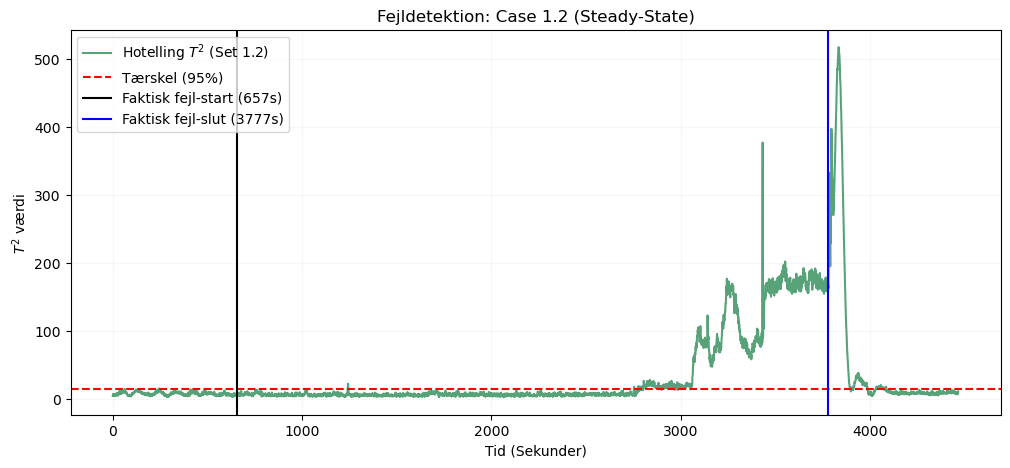

In [ ]:
# 1. Hent sensordata fra Set 1.2
X_test_raw_1_2 = df1_2_sensors.copy() 

# 2. Skaler data med de ORIGINALE trænings-parametre fra din pulje
X_test_1_2 = (X_test_raw_1_2 - train_mu) / train_sigma

# 3. Projektion til PCA-rummet (Scores)
T_test_1_2 = X_test_1_2 @ P

# 4. Beregn T2-værdier (Vektoriseret)
T2_values_1_2 = np.sum((T_test_1_2 @ Sigma_a_inv) * T_test_1_2, axis=1)

# 5. Visualisering af resultatet for 1.2
plt.figure(figsize=(12, 5))
plt.plot(T2_values_1_2, label='Hotelling $T^2$ (Set 1.2)', color='seagreen', alpha=0.8)

# Statistisk tærskel fra træningsfasen
plt.axhline(y=T2_threshold, color='r', linestyle='--', label='Tærskel (95%)')

# Markering af fejl-vinduet for Case 1.2 (Tabel 4)
plt.axvline(x=657, color='black', linestyle='-', label='Faktisk fejl-start (657s)')
plt.axvline(x=3777, color='blue', linestyle='-', label='Faktisk fejl-slut (3777s)') 

#plt.yscale('log')
plt.title('Fejldetektion: Case 1.2 (Steady-State)')
plt.xlabel('Tid (Sekunder)')
plt.ylabel('$T^2$ værdi')
plt.grid(True, which="both", ls="-", alpha=0.1)
plt.legend(loc='upper left')
plt.show()

# Testing the model on data set 1.3
The model is pretty shitty

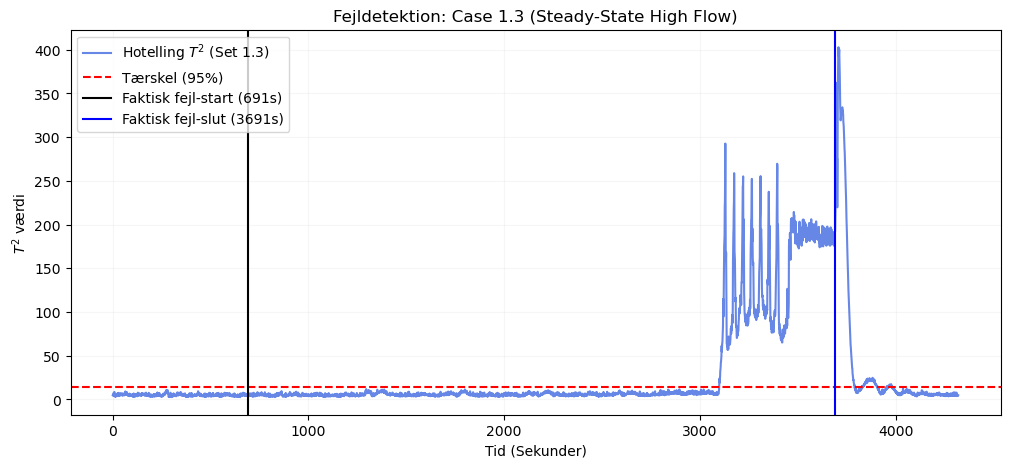

In [ ]:
# 1. Hent sensordata fra Set 1.3
X_test_raw_1_3 = df1_3_sensors.copy() 

# 2. Skaler data med de ORIGINALE trænings-parametre (mu og sigma fra din pulje)
# RETTET: Sørg for at bruge _1_3 her
X_test_1_3 = (X_test_raw_1_3 - train_mu) / train_sigma

# 3. Projektion til PCA-rummet (Scores)
T_test_1_3 = X_test_1_3 @ P

# 4. Beregn T2-værdier (Vektoriseret)
T2_values_1_3 = np.sum((T_test_1_3 @ Sigma_a_inv) * T_test_1_3, axis=1)

# 5. Visualisering af resultatet for 1.3
plt.figure(figsize=(12, 5))
plt.plot(T2_values_1_3, label='Hotelling $T^2$ (Set 1.3)', color='royalblue', alpha=0.8)

# Statistisk tærskel
plt.axhline(y=T2_threshold, color='r', linestyle='--', label='Tærskel (95%)')

# Markering af fejl-vinduet for Case 1.3 (Tabel 4)
plt.axvline(x=691, color='black', linestyle='-', label='Faktisk fejl-start (691s)')
plt.axvline(x=3691, color='blue', linestyle='-', label='Faktisk fejl-slut (3691s)') 

#plt.yscale('log')
plt.title('Fejldetektion: Case 1.3 (Steady-State High Flow)')
plt.xlabel('Tid (Sekunder)')
plt.ylabel('$T^2$ værdi')
plt.grid(True, which="both", ls="-", alpha=0.1)
plt.legend(loc='upper left')
plt.show()

# To do
- Vi skal beslutte om vi vil træne modellen på alt sundt driftsdata (so vi gør), eller om vi hellere vil lave én test ad gangen. Artikeln bruger det hele. 